# Algorithm testing: PC, SDCD, and FGES

## Prelims

Libraries used:

In [ ]:
!pip install numpy pandas matplotlib networkx causaldag dotenv causal-learn sdcd

Everything implemented with no issues using Python 3.11.4

SDCD is known to have kernel crashing issues, make a `.env` file in the same directory as this notebook with the following to fix the issues.

In [3]:
# copy paste into .env:
# MPLCONFIGDIR=/tmp/mpl-cache
# XDG_CACHE_HOME=/tmp/xdg
# IPYTHONDIR=/tmp/ipython
# WANDB_MODE=offline
# OMP_NUM_THREADS=1
# OPENBLAS_NUM_THREADS=1
# MKL_NUM_THREADS=1

from dotenv import load_dotenv
load_dotenv(".env", override=True)

True

In [4]:
import os, sys
from utils_simulate_data import * # from Professor Eberhardt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import causaldag
from causaldag import rand

/Users/justinhong/Documents/fges-py/tempvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Data generation

Modifications made to `utils_simulate_data.py`: made `simulate_linear_continuous_data` also return `adjacency_matrix` to display generated edge weights

Num edges: 15
True ratio: 0.33
True DAG Edges: [(2, 4), (0, 4), (2, 7), (6, 5), (9, 3), (9, 6), (0, 9), (0, 6), (2, 3), (6, 7), (1, 7), (4, 5), (8, 6), (9, 7), (2, 8)]
Is DAG: True


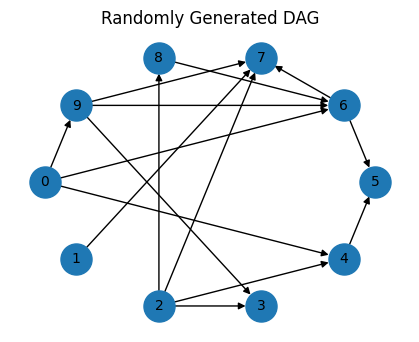

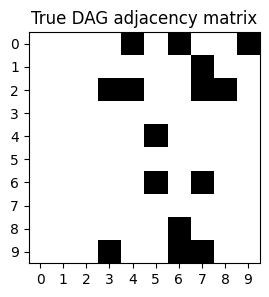

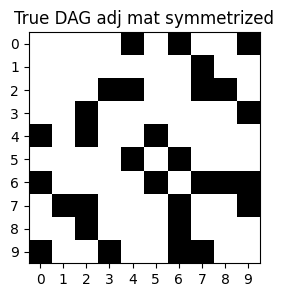

In [5]:
# generate random DAG
num_nodes = 10
random_seed = 42
dag_density = 0.4

np.random.seed(random_seed)
dag = rand.directed_erdos(num_nodes, density=dag_density)
dag_edges = list(dag.arcs)
print(f"Num edges: {len(dag_edges)}")
print(f"True ratio: {len(dag_edges) / (num_nodes * (num_nodes - 1) / 2):.2f}")
print(f"True DAG Edges: {dag_edges}")

# visualize
G = nx.DiGraph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(dag_edges)
plt.figure(figsize=(4,3))
pos = nx.shell_layout(G)
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)
_ = plt.title("Randomly Generated DAG")

print(f'Is DAG: {nx.is_directed_acyclic_graph(G)}')

mat = nx.to_numpy_array(G)
plt.figure(figsize=(4, 3))
_ = plt.imshow(mat, cmap='binary', interpolation='none')
_ = plt.title("True DAG adjacency matrix")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))

truth_symm_mat = mat + np.transpose(mat)
plt.figure(figsize=(4,3))
_ = plt.imshow(truth_symm_mat, cmap='binary', interpolation='nearest')
_ = plt.title('True DAG adj mat symmetrized')
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))

In [6]:
# generate synthetic data using the true DAG
# also generates random edge weights
sample_size = 200
weight_range = (0.25, 0.9)

data, adj_mat = simulate_linear_continuous_data(
    num_of_nodes=num_nodes,
    sample_size=sample_size,
    truth_DAG_directed_edges=dag_edges,
    noise_type='gaussian',
    random_seed=random_seed,
    linear_weight_minabs=weight_range[0],
    linear_weight_maxabs=weight_range[1],
    linear_weight_netative_prob=0.5
)
print(f"\nShape: {data.shape}")
print(f"First 5 rows:\n{data[:5]}")


Shape: (200, 10)
First 5 rows:
[[-0.14346223 -1.58165393  0.64058201  1.49122221  2.14762042 -1.45245454
  -2.27281941  2.41217897  0.86728371 -1.8777939 ]
 [ 0.61700378  0.07900901 -0.81478413  0.53520571 -0.75858812  0.37560964
  -0.81259049 -0.21117675  1.85553607 -0.28083215]
 [ 1.2489407   1.06069246  1.84698033 -0.03535535 -0.79074968  1.79255278
   2.54166304 -3.22189593  0.08251867  2.84532414]
 [ 0.06564916  0.23748525  0.26595527  1.29599431  1.47695793 -0.46970508
  -1.68061029  1.19782044  2.21497637 -1.26597401]
 [ 1.16920765 -0.31736879 -0.21347264  2.46273204  1.46351409 -3.63984671
  -2.77788339  1.79937762 -0.4796587  -2.19806479]]


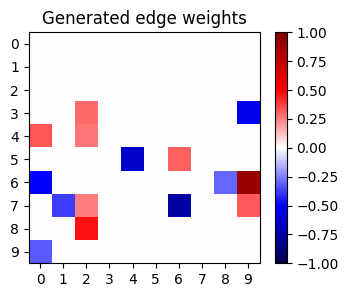

In [7]:
# visualize the generated edge weights
plt.figure(figsize=(4,3))
_ = plt.imshow(adj_mat, cmap='seismic', vmin=-1, vmax=1)
_ = plt.title("Generated edge weights")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

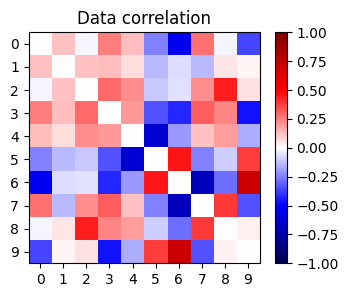

In [8]:
# data correlations
data_corr = np.corrcoef(data, rowvar=False)
np.fill_diagonal(data_corr, 0)
plt.figure(figsize=(4,3))
_ = plt.imshow(data_corr, cmap='seismic', vmin=-1, vmax=1)
_ = plt.title("Data correlation")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

## PC estimation

Running PC algorithm on simulated data to uncover known ground truth

### Single-run example

Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 811.03it/s]


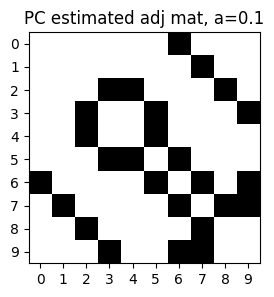

In [9]:
from causallearn.search.ConstraintBased.PC import pc

# Run PC algorithm with some alpha
alpha = 0.1

cg = pc(data, alpha=alpha, indep_test='fisherz')
pdag_mat = cg.G.graph
adj_mat = np.abs(pdag_mat)
plt.figure(figsize=(4,3))
_ = plt.imshow(adj_mat, cmap='binary', interpolation='nearest')
_ = plt.title(f"PC estimated adj mat, a={alpha}")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))

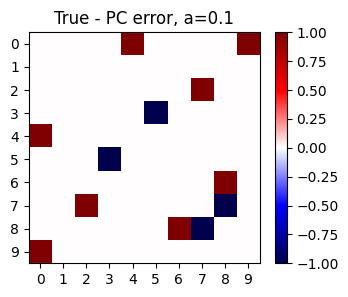

In [10]:
# visualize (true - estimated) error
plt.figure(figsize=(4,3))
_ = plt.imshow(truth_symm_mat - adj_mat, cmap='seismic', vmin=-1, vmax=1)
_ = plt.title(f"True - PC error, a={alpha}")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

NOTE: in true - algo model error plots, an error of 1 (red) means that the algo mistakenly placed an edge where there is none in the ground truth, and an error of -1 (blue) means that the algo missed an edge that is present in the ground truth. 

### Sweep alphas to find optimal

Ideally we observe a "U" shaped curve in error vs alpha (too sparse -> omits true edges, too dense -> includes false edges), and optimal alpha at the bottom of the dip. This pattern should ideally be observed when sweeping any sparsity-controlling parameter for any algorithm, not just PC.

Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 438.18it/s]


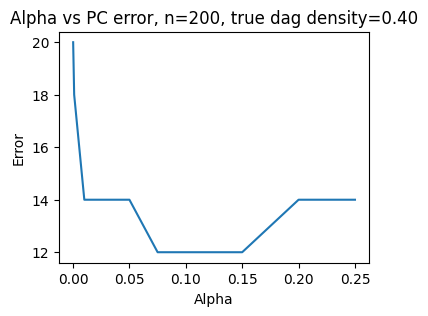

In [11]:
alphas = [0.0001, 0.001, 0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25]
errs = []

for alpha in alphas:
    cg = pc(data, alpha=alpha, indep_test='fisherz')
    pdag_mat = cg.G.graph
    adj_mat = np.abs(pdag_mat)
    err = np.sum(np.abs(truth_symm_mat - adj_mat))
    errs.append(err)

plt.figure(figsize=(4,3))
plt.plot(alphas, errs)
_ = plt.xlabel("Alpha")
_ = plt.ylabel("Error")
_ = plt.title(f"Alpha vs PC error, n={sample_size}, true dag density={dag_density:.2f}")

Depth=3, working on node 9: 100%|██████████| 10/10 [00:00<00:00, 840.19it/s]


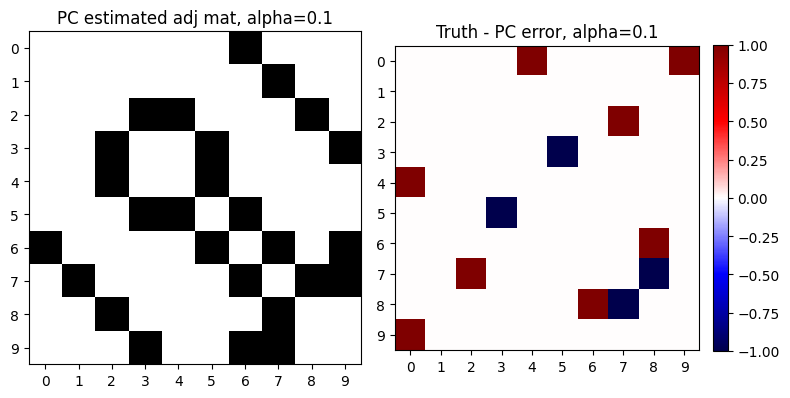

In [12]:
# plot and display at optimal alpha
alpha = 0.1

cg = pc(data, alpha=alpha, indep_test='fisherz')
pdag_mat = cg.G.graph
adj_mat = np.abs(pdag_mat)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(adj_mat, cmap='binary', interpolation='nearest', vmax=1)
axs[0].set_title(f"PC estimated adj mat, alpha={alpha}")
axs[0].set_xticks(range(num_nodes))
axs[0].set_yticks(range(num_nodes))

im = axs[1].imshow(truth_symm_mat - adj_mat, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title(f"Truth - PC error, alpha={alpha}")
axs[1].set_xticks(range(num_nodes))
axs[1].set_yticks(range(num_nodes))

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()

### Estimated correlation

Recover estimated correlation matrix and compare to correlation matrix of generated data

The `estimate_parameters` file is copy pasted from the exercises folder

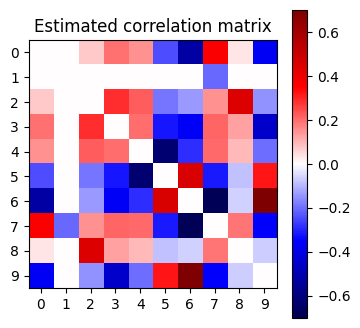

In [13]:
from causallearn.utils.PDAG2DAG import pdag2dag
from estimate_parameters import estimate_parameters, get_correlation_matrix # from exercise 3

g_dag = pdag2dag(cg.G)
edge_params, residuals = estimate_parameters(g_dag.graph, data)
est_corr = get_correlation_matrix(edge_params, residuals)
np.fill_diagonal(est_corr, 0)

fig,ax = plt.subplots(figsize=(4,4))
vbound = np.nanmax(np.abs(est_corr))
im = ax.imshow(est_corr, cmap='seismic', vmin=-vbound, vmax=vbound)
ax.set_xticks(range(num_nodes))
ax.set_yticks(range(num_nodes))
ax.set_xticklabels(range(num_nodes))
ax.set_yticklabels(range(num_nodes))
ax.set_title('Estimated correlation matrix')
_ = plt.colorbar(im, ax=ax)

In [14]:
# compare data-generated vs estimated correlation matrices
true_vec = data_corr[np.tril_indices(data_corr.shape[0],-1)].flatten()
est_vec = est_corr[np.tril_indices(est_corr.shape[0],-1)].flatten()
print(np.corrcoef(true_vec, est_vec)[0,1])

0.9623718358580446


## SDCD estimation

Stable Differentiable Causal Discovery (https://arxiv.org/pdf/2311.10263) (https://github.com/azizilab/sdcd)

Tested sparsity controllers:

stage1 threshold: preliminary edge pruning

stage2 threshold: irrelevant? no effect on outputted model based on observations

display threshold: display binary adj mat for all edges with confidence > threshold

Note: using display_thresh=0 for SDCD displays the calculated continuous weights rather than a binary adjacency matrix.

Not tested:

alpha/beta 1 and 2: penalty coefficients in SDCD objective function

More notes on SDCD parameters:

stage1 threshold: SDCD is a two-part algorithm. In stage 1 it runs the optimization problem without acyclicity constraints, and then prunes edges with calculated continuous weight < stage 1 threshold.

stage2 threshold: supposedly another threshold applied after stage 2 (optimization with constraint), but in practice it doesn't seem to have any effect on the outputted model. Hypothesis: functionally the same as display threshold or for the tested stage 1 thresholds the stage 2 thresholds previously checked do not end up pruning any additional edges after stage 1 pruning. 

display threshold: after the algorithm is finished running and outputs a model with continuous edge weights, simply acts as a threshold for displaying the final binary adjacency matrix. This does not affect the optimization process or the actual underlying model, just the visualization of the model.

alphas/betas: penalty coefficients in the SDCD objective function, changes the actual optimization problem.

### Single-run example

In [15]:
from sdcd import SDCD
from sdcd.utils import create_intervention_dataset
import pandas as pd

X_df = pd.DataFrame(data, columns=[str(i) for i in range(num_nodes)])
X_df['perturbation_label'] = 'obs'
X_dataset = create_intervention_dataset(X_df, perturbation_colname='perturbation_label')

In [16]:
stage1_param = 0.01 # default 0.2
alpha1 = 1e-2       # default 1e-2
stage2_thresh = 0.9 # default 0.1, irrelevant?
alpha2 = 5e-4       # default 5e-4

model = SDCD()
model.train(
    X_dataset,
    finetune=True,
    stage1_kwargs={
        'mask_threshold': stage1_param,
        'alpha': alpha1
    },
    stage2_kwargs={
        'threshold': stage2_thresh,
        'alpha': alpha2
    }
)

Epoch 0: loss=19.99, gamma=0.00
Epoch 100: loss=15.46, gamma=0.00
Epoch 200: loss=14.43, gamma=0.00
Epoch 300: loss=13.90, gamma=0.00
Epoch 400: loss=13.64, gamma=0.00
Epoch 500: loss=13.50, gamma=0.00
Epoch 600: loss=13.39, gamma=0.00
Epoch 700: loss=13.31, gamma=0.00
Epoch 800: loss=13.24, gamma=0.00
Early stopping triggered.
Fraction of possible edges in mask: 0.76
Epoch 0: loss=19.85, gamma=0.00
Epoch 100: loss=17.03, gamma=0.50
Epoch 200: loss=16.19, gamma=1.00
Epoch 300: loss=15.71, gamma=1.40
Epoch 400: loss=15.37, gamma=1.40
Epoch 500: loss=15.27, gamma=1.40
Epoch 600: loss=15.16, gamma=1.40
Epoch 700: loss=15.10, gamma=1.40
Epoch 800: loss=15.06, gamma=1.40
Epoch 900: loss=14.98, gamma=1.40
Epoch 1000: loss=14.94, gamma=1.40
Epoch 1100: loss=14.91, gamma=1.40
Epoch 1200: loss=14.90, gamma=1.40
Epoch 1300: loss=14.86, gamma=1.40
Epoch 1400: loss=14.88, gamma=1.40
Epoch 1500: loss=14.83, gamma=1.40
Epoch 1600: loss=14.81, gamma=1.40
Epoch 1700: loss=14.81, gamma=1.40
Early stopp

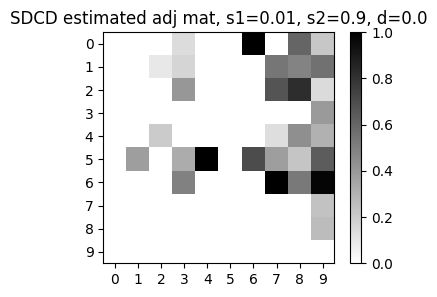

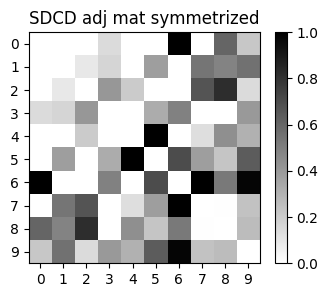

In [17]:
display_thresh = 0.0
sdcd_adj = model.get_adjacency_matrix(threshold=display_thresh)

plt.figure(figsize=(4,3))
_ = plt.imshow(sdcd_adj, cmap='binary', interpolation='nearest', vmax=1)
_ = plt.title(f"SDCD estimated adj mat, s1={stage1_param}, s2={stage2_thresh}, d={display_thresh}")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

sdcd_symm_adj = sdcd_adj + np.transpose(sdcd_adj)
sdcd_symm_adj = np.minimum(sdcd_symm_adj, 1) # for binary error purposes
plt.figure(figsize=(4,3))
_ = plt.imshow(sdcd_symm_adj, cmap='binary', interpolation='nearest', vmax=1)
_ = plt.title(f"SDCD adj mat symmetrized")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

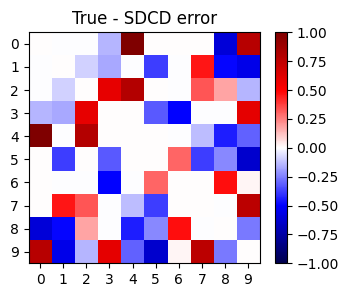

In [18]:
plt.figure(figsize=(4,3))
diff_mat = truth_symm_mat - sdcd_symm_adj
_ = plt.imshow(diff_mat, cmap='seismic', vmin=-1, vmax=1)
_ = plt.title(f"True - SDCD error")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

NOTE: errors may seem very present in the above graph because we are calculating erorr in this case with (binary matrix) - (continuous weight matrix), looks a lot more incorrect than it would be with display thresholding

### Sweep display threshold

Made irrelevant by sweeping both stage1 threshold + display (in the following section), simply for tutorial purposes

In [19]:
stage1_param = 0.2  # default 0.2
alpha1 = 1e-2       # default 1e-2
stage2_thresh = 0.1 # default 0.1, irrelevant?
alpha2 = 5e-4       # default 5e-4

model = SDCD()
model.train(
    X_dataset,
    finetune=False,
    stage1_kwargs={
        'mask_threshold': stage1_param,
        'alpha': alpha1
    },
    stage2_kwargs={
        'threshold': stage2_thresh,
        'alpha': alpha2
    }
)

Epoch 0: loss=19.99, gamma=0.00
Epoch 100: loss=15.46, gamma=0.00
Epoch 200: loss=14.43, gamma=0.00
Epoch 300: loss=13.90, gamma=0.00
Epoch 400: loss=13.64, gamma=0.00
Epoch 500: loss=13.50, gamma=0.00
Epoch 600: loss=13.39, gamma=0.00
Epoch 700: loss=13.31, gamma=0.00
Epoch 800: loss=13.24, gamma=0.00
Early stopping triggered.
Fraction of possible edges in mask: 0.47
Epoch 0: loss=19.85, gamma=0.00
Epoch 100: loss=17.06, gamma=0.50
Epoch 200: loss=16.17, gamma=1.00
Epoch 300: loss=15.74, gamma=1.50
Epoch 400: loss=15.45, gamma=1.50
Epoch 500: loss=15.28, gamma=1.50
Epoch 600: loss=15.17, gamma=1.50
Epoch 700: loss=15.17, gamma=1.50
Epoch 800: loss=15.06, gamma=1.50
Epoch 900: loss=15.02, gamma=1.50
Epoch 1000: loss=15.02, gamma=1.50
Epoch 1100: loss=14.97, gamma=1.50
Epoch 1200: loss=14.95, gamma=1.50
Epoch 1300: loss=14.97, gamma=1.50
Epoch 1400: loss=15.01, gamma=1.50
Epoch 1500: loss=14.94, gamma=1.50
Epoch 1600: loss=15.02, gamma=1.50
Early stopping triggered.
Finished training in

minimum err 14.0 at display thresholds: [0.38, 0.39, 0.63, 0.64]


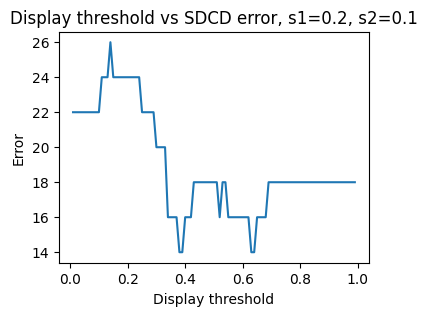

In [20]:
# sweep display threshold
d_params = [0.01 * i for i in range(1, 100)]
adj_mats = []
errs = []

for dp in d_params:
    sdcd_adj = model.get_adjacency_matrix(threshold=dp)
    adj_mats.append(sdcd_adj)
    sdcd_symm_adj = sdcd_adj + np.transpose(sdcd_adj)
    sdcd_symm_adj = np.minimum(sdcd_symm_adj, 1)

    err = np.sum(np.abs(truth_symm_mat - sdcd_symm_adj))
    errs.append(err)

plt.figure(figsize=(4,3))
plt.plot(d_params, errs)
_ = plt.xlabel("Display threshold")
_ = plt.ylabel("Error")
_ = plt.title(f"Display threshold vs SDCD error, s1={stage1_param}, s2={stage2_thresh}")

# find min
errs_arr = np.array(errs)
min_err = errs_arr.min()
min_idxs = np.where(errs_arr == min_err)[0]
best_dps = [d_params[i] for i in min_idxs]
print(f"minimum err {min_err} at display thresholds: {best_dps}")

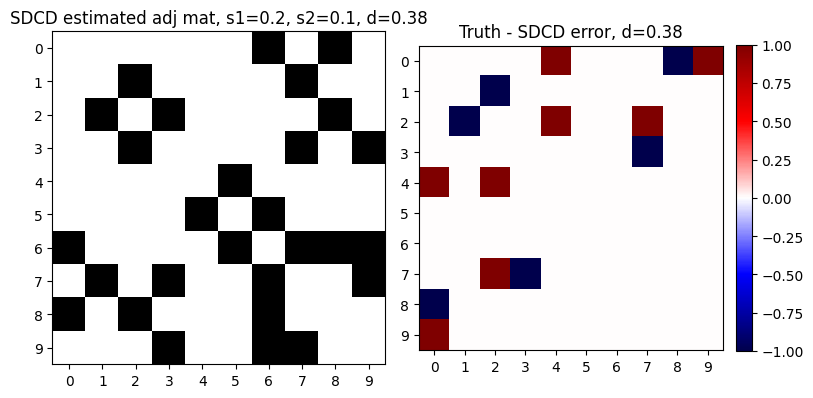

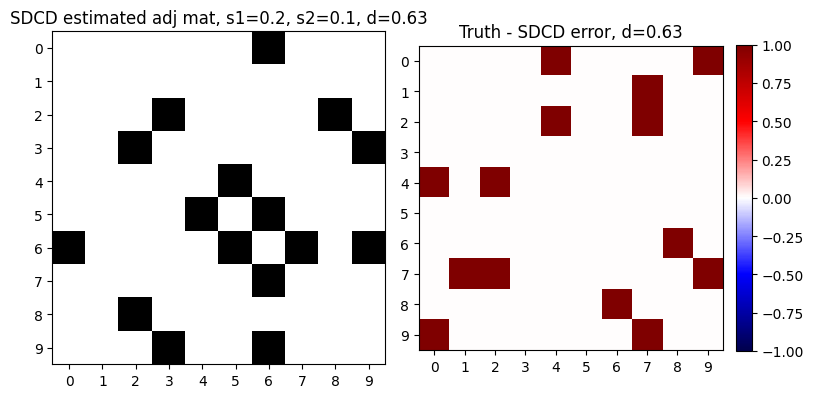

In [21]:
# plot at optimal display threshs
display_thresh_1 = 0.38
sdcd_adj = model.get_adjacency_matrix(threshold=display_thresh_1)
symm_sdcd_1 = sdcd_adj + np.transpose(sdcd_adj)

display_thresh_2 = 0.63
sdcd_adj = model.get_adjacency_matrix(threshold=display_thresh_2)
symm_sdcd_2 = sdcd_adj + np.transpose(sdcd_adj)

# plot 1
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(symm_sdcd_1, cmap='binary', interpolation='nearest', vmax=1)
axs[0].set_title(f"SDCD estimated adj mat, s1={stage1_param}, s2={stage2_thresh}, d={display_thresh_1}")
axs[0].set_xticks(range(num_nodes))
axs[0].set_yticks(range(num_nodes))

im = axs[1].imshow(truth_symm_mat - symm_sdcd_1, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title(f"Truth - SDCD error, d={display_thresh_1}")
axs[1].set_xticks(range(num_nodes))
axs[1].set_yticks(range(num_nodes))

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()

# plot 2
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(symm_sdcd_2, cmap='binary', interpolation='nearest', vmax=1)
axs[0].set_title(f"SDCD estimated adj mat, s1={stage1_param}, s2={stage2_thresh}, d={display_thresh_2}")
axs[0].set_xticks(range(num_nodes))
axs[0].set_yticks(range(num_nodes))

im = axs[1].imshow(truth_symm_mat - symm_sdcd_2, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title(f"Truth - SDCD error, d={display_thresh_2}")
axs[1].set_xticks(range(num_nodes))
axs[1].set_yticks(range(num_nodes))

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()

Note: comparing d=0.4 and d=0.6 errors seems unintuitive. if d=0.4 is too dense (false edges at (2,1), (7,3), and (8,0)), and d=0.6 is too sparse (omits true edges at (1,7), (6,8), and (7,9)), then d=0.5 should be optimal, but it isn't based on loss graph. probably because of some idiosyncrasies, reconciled in s1 thresh + display sweep

### Sweep stage 1 thresh and display threshold

In [22]:
# sweeping stage1 thresh and display
# display generation very fast, not a time hindrance to sweep both s1 and display
s1s = [0.01] + [0.1 * i for i in range(1, 10)]

alpha1 = 1e-2       # default 1e-2
stage2_thresh = 0.1 # default 0.1, irrelevant?
alpha2 = 5e-4       # default 5e-4

fin_errs = []
opt_display_threshs = []

for s1 in s1s:
    model = SDCD()
    model.train(
        X_dataset,
        finetune=False,
        stage1_kwargs={
            'mask_threshold': s1,
            'alpha': alpha1
        },
        stage2_kwargs={
            'threshold': stage2_thresh,
            'alpha': alpha2
        }
    )

    # sweep display threshold
    d_params = [0.01 * i for i in range(1, 100)]
    dp_errs = []
    for dp in d_params:
        sdcd_adj = model.get_adjacency_matrix(threshold=dp)
        sdcd_symm_adj = sdcd_adj + np.transpose(sdcd_adj)
        sdcd_symm_adj = np.minimum(sdcd_symm_adj, 1)
        err = np.sum(np.abs(truth_symm_mat - sdcd_symm_adj))
        dp_errs.append(err)

    # find min display thresh for specific s1
    dp_errs_arr = np.array(dp_errs)
    min_dp_err = dp_errs_arr.min()
    min_dp_idxs = np.where(dp_errs_arr == min_dp_err)[0]
    best_dp = [d_params[i] for i in min_dp_idxs][0]
    opt_display_threshs.append(best_dp)
    fin_errs.append(min_dp_err)

Epoch 0: loss=19.99, gamma=0.00
Epoch 100: loss=15.46, gamma=0.00
Epoch 200: loss=14.43, gamma=0.00
Epoch 300: loss=13.90, gamma=0.00
Epoch 400: loss=13.64, gamma=0.00
Epoch 500: loss=13.50, gamma=0.00
Epoch 600: loss=13.39, gamma=0.00
Epoch 700: loss=13.31, gamma=0.00
Epoch 800: loss=13.24, gamma=0.00
Early stopping triggered.
Fraction of possible edges in mask: 0.76
Epoch 0: loss=19.85, gamma=0.00
Epoch 100: loss=17.03, gamma=0.50
Epoch 200: loss=16.19, gamma=1.00
Epoch 300: loss=15.71, gamma=1.40
Epoch 400: loss=15.37, gamma=1.40
Epoch 500: loss=15.27, gamma=1.40
Epoch 600: loss=15.16, gamma=1.40
Epoch 700: loss=15.10, gamma=1.40
Epoch 800: loss=15.06, gamma=1.40
Epoch 900: loss=14.98, gamma=1.40
Epoch 1000: loss=14.94, gamma=1.40
Epoch 1100: loss=14.91, gamma=1.40
Epoch 1200: loss=14.90, gamma=1.40
Epoch 1300: loss=14.86, gamma=1.40
Epoch 1400: loss=14.88, gamma=1.40
Epoch 1500: loss=14.83, gamma=1.40
Epoch 1600: loss=14.81, gamma=1.40
Epoch 1700: loss=14.81, gamma=1.40
Early stopp

[0.64, 0.38, 0.38, 0.3, 0.48, 0.01, 0.01, 0.6, 0.01, 0.01]


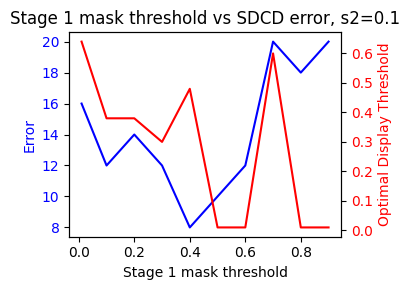

In [23]:
# plot 
fig, ax1 = plt.subplots(figsize=(4,3))
ax1.plot(s1s, fin_errs, 'b-', label='Error')
ax1.set_xlabel("Stage 1 mask threshold")
ax1.set_ylabel("Error", color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(s1s, opt_display_threshs, 'r-', label='Optimal Display Threshold')
ax2.set_ylabel("Optimal Display Threshold", color='r')
ax2.tick_params(axis='y', labelcolor='r')

_ = plt.title(f"Stage 1 mask threshold vs SDCD error, s2={stage2_thresh}")
fig.tight_layout()

print(opt_display_threshs)

Note: we have our optimal at s1=0.4 and display=0.48. A quick sanity check is seeing that display thresholds decrease as s1 thresholds increase (display starts to force the displayed graph to be more sparse as s1 threshold increases and the underlying graph becomes less sparse).

From earlier: display=0.4, 0.6 seemed to be optimal with different types of errors, but doesn't make sense that display=0.5 is not optimal. Now we see that with the right s1 threshold, display=0.5 is indeed optimal, reconciling the earlier unintuitive observation.

Epoch 0: loss=19.99, gamma=0.00
Epoch 100: loss=15.46, gamma=0.00
Epoch 200: loss=14.43, gamma=0.00
Epoch 300: loss=13.90, gamma=0.00
Epoch 400: loss=13.64, gamma=0.00
Epoch 500: loss=13.50, gamma=0.00
Epoch 600: loss=13.39, gamma=0.00
Epoch 700: loss=13.31, gamma=0.00
Epoch 800: loss=13.24, gamma=0.00
Early stopping triggered.
Fraction of possible edges in mask: 0.31
Epoch 0: loss=19.85, gamma=0.00
Epoch 100: loss=17.16, gamma=0.50
Epoch 200: loss=16.37, gamma=1.00
Epoch 300: loss=15.76, gamma=1.40
Epoch 400: loss=15.43, gamma=1.40
Epoch 500: loss=15.28, gamma=1.40
Epoch 600: loss=15.11, gamma=1.40
Epoch 700: loss=15.06, gamma=1.40
Epoch 800: loss=14.99, gamma=1.40
Epoch 900: loss=14.97, gamma=1.40
Epoch 1000: loss=14.97, gamma=1.40
Epoch 1100: loss=14.92, gamma=1.40
Epoch 1200: loss=14.91, gamma=1.40
Epoch 1300: loss=14.90, gamma=1.40
Epoch 1400: loss=14.88, gamma=1.40
Epoch 1500: loss=14.90, gamma=1.40
Early stopping triggered.
Finished training in 12.5915367603302 seconds.


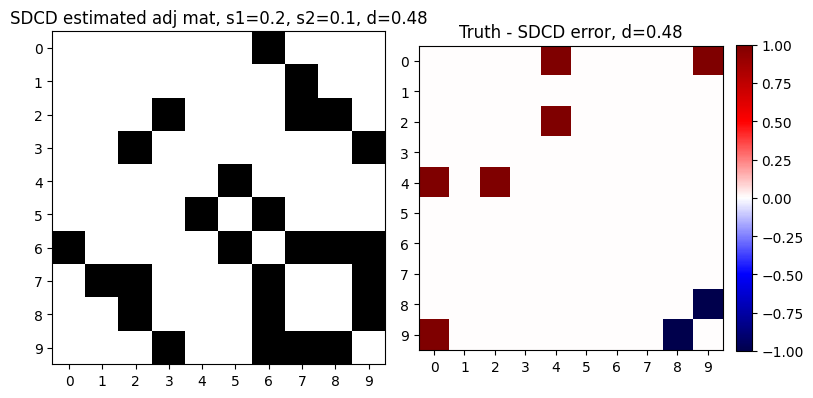

In [24]:
# plot at optimal
# s1=0.4, d=0.48

s1 = 0.4
s2 = 0.1
d = 0.48

model = SDCD()
model.train(
    X_dataset,
    finetune=False,
    stage1_kwargs={
        'mask_threshold': s1,
        'alpha': alpha1
    },
    stage2_kwargs={
        'threshold': s2,
        'alpha': alpha2
    }
)

optimized_sdcd_adj = model.get_adjacency_matrix(threshold=d)
symm_sdcd_1 = optimized_sdcd_adj + np.transpose(optimized_sdcd_adj)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(symm_sdcd_1, cmap='binary', interpolation='nearest', vmax=1)
axs[0].set_title(f"SDCD estimated adj mat, s1={stage1_param}, s2={stage2_thresh}, d={d}")
axs[0].set_xticks(range(num_nodes))
axs[0].set_yticks(range(num_nodes))

im = axs[1].imshow(truth_symm_mat - symm_sdcd_1, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title(f"Truth - SDCD error, d={d}")
axs[1].set_xticks(range(num_nodes))
axs[1].set_yticks(range(num_nodes))

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()

### Estimated correlation

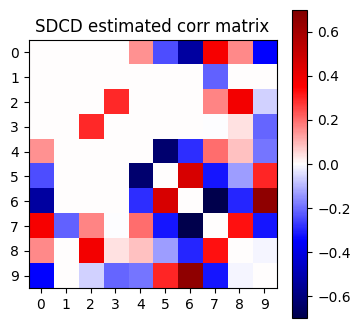

In [25]:
# optimized_sdcd_adj not symmetrized
# need to convert to causallearn graph
cl_graph = np.zeros((num_nodes, num_nodes))
for i in range(num_nodes):
    for j in range(num_nodes):
        if optimized_sdcd_adj[i, j] == 1:  
            cl_graph[j, i] = 1
            cl_graph[i, j] = -1

edge_params, residuals = estimate_parameters(cl_graph, data)
est_corr = get_correlation_matrix(edge_params, residuals)
np.fill_diagonal(est_corr, 0)

fig,ax = plt.subplots(figsize=(4,4))
vbound = np.nanmax(np.abs(est_corr))
im = ax.imshow(est_corr, cmap='seismic', vmin=-vbound, vmax=vbound)
ax.set_xticks(range(num_nodes))
ax.set_yticks(range(num_nodes))
ax.set_xticklabels(range(num_nodes))
ax.set_yticklabels(range(num_nodes))
ax.set_title('SDCD estimated corr matrix')
_ = plt.colorbar(im, ax=ax)

In [26]:
# compare data-generated vs estimated correlation matrices
true_vec = data_corr[np.tril_indices(data_corr.shape[0],-1)].flatten()
est_vec = est_corr[np.tril_indices(est_corr.shape[0],-1)].flatten()
print(np.corrcoef(true_vec, est_vec)[0,1])

0.8894497153499439


## FGES estimation

### Single-run example

In [28]:
# sys.path.append('../fges-py')
sys.path.append('../') # change based on your fges-py directory
from SEMScore import *
from fges import *
from SemEstimator import SemEstimator

In [29]:
# functions from exercise_3
def infer_edges(data, s=8):
    '''
    Arguments:
        data : an n_samples x n_nodes array
        s : sparsity parameter for FGES (default = 8 as was used in Dubois et al.)
    Returns:
        edges : a list of tuples, where each tuple (i,j) represents an edge 
                found between node i and node j
        fges_result : dict of results from fges.search() (needed for estimating
                      the correlation matrix later on)
    '''

    # FGES takes a score function that depends on the data and a user-determined
    # sparsity level (penalty discount)
    score = SEMBicScore(penalty_discount=s, dataset=data)

    # run FGES
    fges = FGES(range(data.shape[1]), score, filename=data)
    fges_result = fges.search()
    edges = fges_result['graph'].edges()
    return edges, fges_result

# convert list of edges that fges returns to an adjacency matrix where entries
# (i,j) and (j,i) are 1 if there is an edge between node i and node j and 0 otherwise
def fges_edges_to_mat(edges, n_nodes):
    adj_mat = np.zeros((n_nodes,n_nodes))
    for edge in edges:
        adj_mat[edge[0], edge[1]] = 1
        adj_mat[edge[1], edge[0]] = 1
    return adj_mat

def estimate_corr(data, fges_result):
    '''
    Arguments:
        data : an n_samples x n_nodes numpy array
        fges_result : a dict of results returned by fges.search()
    Returns:
        est_corr : an n_nodes x n_nodes numpy array estimated correlation matrix
    '''
    sem_est = SemEstimator(data, sparsity=4)

    # provide to the estimator the DAG found above
    sem_est.pattern = fges_result['graph']

    # estimate the weights and residuals
    sem_est.estimate()

    # get covariance matrix from SemEstimator
    est_cov = sem_est.graph_cov

    # compute correlation matrix from covariance matrix
    stdistdj = np.sqrt(np.diag(est_cov))
    est_corr = est_cov / np.outer(stdistdj, stdistdj)
    return est_corr

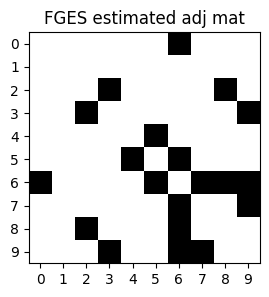

In [30]:
sparsity_param = 2 # default 8, increase = more sparse

edges,fges_result = infer_edges(data, s=sparsity_param)
adj_mat = fges_edges_to_mat(edges, data.shape[1])

plt.figure(figsize=(4,3))
_ = plt.imshow(adj_mat, cmap='binary', interpolation='nearest')
_ = plt.title("FGES estimated adj mat")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))

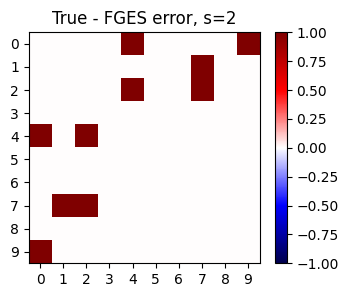

In [31]:
plt.figure(figsize=(4,3))
_ = plt.imshow(truth_symm_mat - adj_mat, cmap='seismic', vmin=-1, vmax=1)
_ = plt.title(f"True - FGES error, s={sparsity_param}")
_ = plt.xticks(range(num_nodes))
_ = plt.yticks(range(num_nodes))
_ = plt.colorbar()

### Sweep sparsity parameter to find optimal

min error 6.0 at sparsity parameters [1.4]


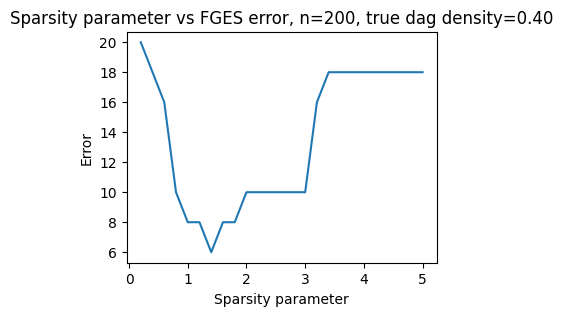

In [32]:
s_params = [0.2*i for i in range(1, 21)] + [5]
errs = []

for sp in s_params:
    edges,fges_result = infer_edges(data, s=sp)
    adj_mat = fges_edges_to_mat(edges, data.shape[1])
    err = np.sum(np.abs(truth_symm_mat - adj_mat))
    errs.append(err)

plt.figure(figsize=(4,3))
plt.plot(s_params, errs)
_ = plt.xlabel("Sparsity parameter")
_ = plt.ylabel("Error")
_ = plt.title(f"Sparsity parameter vs FGES error, n={sample_size}, true dag density={dag_density:.2f}")

min_err = min(errs)
opt_idxs = np.where(np.array(errs) == min_err)[0]
opt_spars = [round(s_params[i], 2) for i in opt_idxs]
print(f"min error {min_err} at sparsity parameters {opt_spars}")

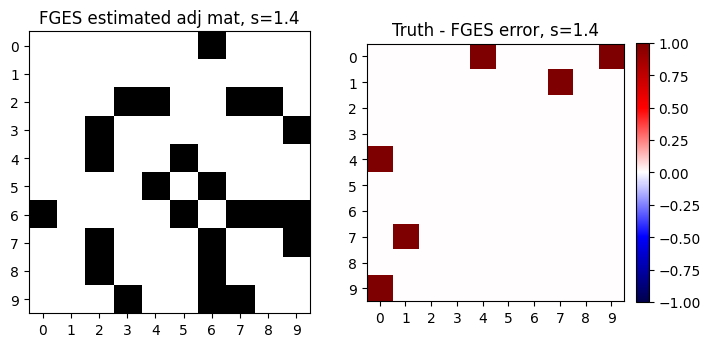

In [33]:
# plot at optimal
# s = 1.4

opt_s = 1.4

edges,fges_result = infer_edges(data, s=opt_s)
adj_mat = fges_edges_to_mat(edges, data.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
_ = axs[0].imshow(adj_mat, cmap='binary', interpolation='nearest', vmax=1)
_ = axs[0].set_title(f"FGES estimated adj mat, s={opt_s}")
_ = axs[0].set_xticks(range(num_nodes))
_ = axs[0].set_yticks(range(num_nodes))

im = axs[1].imshow(truth_symm_mat - adj_mat, cmap='seismic', vmin=-1, vmax=1)
_ = axs[1].set_title(f"Truth - FGES error, s={opt_s}")
_ = axs[1].set_xticks(range(num_nodes))
_ = axs[1].set_yticks(range(num_nodes))
_ = fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

### Estimated correlation

/Users/justinhong/Documents/fges-py/algo_testing/../search_util.py:172: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  params, r, _, _ = np.linalg.lstsq(a, b)


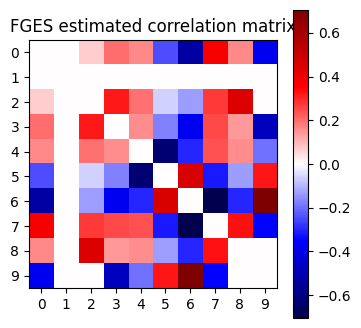

In [34]:
est_corr = estimate_corr(data, fges_result)
np.fill_diagonal(est_corr, 0)

fig,ax = plt.subplots(figsize=(4,4))
vbound = np.nanmax(np.abs(est_corr))
im = ax.imshow(est_corr, cmap='seismic', vmin=-vbound, vmax=vbound)
ax.set_xticks(range(num_nodes))
ax.set_yticks(range(num_nodes))
ax.set_xticklabels(range(num_nodes))
ax.set_yticklabels(range(num_nodes))
ax.set_title('FGES estimated correlation matrix')
_ = plt.colorbar(im, ax=ax)

In [35]:
# compare data-generated vs estimated correlation matrices
true_vec = data_corr[np.tril_indices(data_corr.shape[0],-1)].flatten()
est_vec = est_corr[np.tril_indices(est_corr.shape[0],-1)].flatten()
print(np.corrcoef(true_vec, est_vec)[0,1])

0.9685922799135681
